### Who Hires Fired Police Officers? Examining the Network of Wandering Officers in Illinois

By Jinny Kim

This project examines the network of wandering officers in Illinois, using police employment history data between 2000 and present. This aims to identify whether there are established networks where fired officers are flowing to and fro and which agencies are hiring disproportionately high numbers of fired officers compared to their size. 

I hope to identify problematic agencies through this analysis that serves as a jumping point for a deeper investigation into the phenomenon of wandering officers in the state of Illinois. 

##### Background

["Wandering officers"](https://scholarship.law.duke.edu/cgi/viewcontent.cgi?article=6701&context=faculty_scholarship) are law enforcement officers who are fired, often for a misconduct, who are then hired by another agency. By jumping around to different agencies, police officers are able to avoid accountability. Media has covered this issue, such as the case involving Ron Navarreta. Navarreta was an officer fired from the Inglewood Police Department in 2005 after a child pornography investigation. He was hired by the McFarland Police Department, an agency which by 2011, had hired 13 officers who had been forced out of their previous positions, according to the [Associated Press](https://pulitzercenter.org/stories/wandering-cops-shuffle-departments-abusing-citizens). 

A 2020 [Yale Law Journal article](https://scholarship.law.duke.edu/cgi/viewcontent.cgi?article=6701&context=faculty_scholarship), the first systematic investigation of wandering officers, focused on Florida, found that fired officers tend to move to smaller agencies, often in communities of colour. The analysis also concluded that wandering officers are more likely to receive a complaint than new officers or those who weren't previously fired. Hence, identifying how wandering officers float around and find new work in Illinois could be an important step to ensuring community safety against police misconduct.  

##### Data & Methodology

This analysis uses the National Police Index (NPI) data, a project launched in 2024 as a collaboration between news and legal organizations. This dataset includes officers' employment history, including the start and end dates at each agency and the reason for separation. 

I identify officers who were separated for being charged or convicted of crime, removed from the roster by the department, terminated for a cause or decertified by the board. While I cannot identify the precise reasons for their separations, filtering on these separation reasons can approximate wandering officers within the dataset.

I construct a directed network where nodes are agencies and edges run from the origin agency, where an officer was previously employed, to the destination agency, where they were subsequently hired. The weight of each directed edge equals the total number of officer hirings. If an officer is fired and rehired multiple times, each re-hiring contributes to the weight of the corresponding edge. 

I then conduct network-level and node-level descriptive statistics to offer a higher-level look at the network of wandering officers in Illinois as well as any connections between the agencies. 

In [1]:
import polars as pl
import pandas as pd
import json
import networkx as nx
import matplotlib.pyplot as plt
import altair as alt

In [2]:
# Import the National Police Index data, then filter to Illinois from 2000

illinois = pl.read_csv("raw/illinois-processed.csv",
                       schema_overrides={
                           "start_date": pl.Date,
                           "end_date": pl.Date
                        })

IL_police = illinois.filter(pl.col("start_date").dt.year() >= 2000)

In [ ]:
# @markdown Import the full UCR data and write the IL subset to CSV

# ucr_employees = (
#     pl.read_csv("raw/lee_1960_2025.csv")
#     .filter(pl.col("state_abbr") == "IL")
# )

# ucr_employees.write_csv("output/ucr_employees.csv")

In [3]:
# Import UCR dataset

ucr_employees = pl.read_csv("output/ucr_employees.csv")

In [4]:
# Flag officers who were likely fired for misconduct

misconduct = ["Charged/convicted Of Crime", "Decertified By Board",
              "Removed From Roster By Department", "Terminated For Cause"]

fired_officers = IL_police.with_columns(
    pl.when(pl.col("separation_reason").is_in(misconduct))
    .then(1)
    .otherwise(0)
    .alias("fired_for_misconduct")
)

fired_officers = fired_officers.sort(["person_nbr", "start_date"])

In [5]:
# Filter to misconduct-related termination episodes 

misconduct_firing = (
    fired_officers.filter(pl.col("fired_for_misconduct") == 1)
    .select(["person_nbr", "end_date", "separation_reason", "agency_name", "state"])
    .rename({"end_date": "termination_date"})
    .with_row_index("episode_id")
)

# Merge back employment records after each termination episode

post_misconduct = (
    fired_officers.join(misconduct_firing, on="person_nbr", how="inner")
    .filter(pl.col("start_date") > pl.col("termination_date"))
)

# Merge the two datasets so that each row is termination and the next employment 

next_hire = (
    post_misconduct
    .sort(["episode_id", "start_date"])
    .group_by("episode_id")
    .agg(pl.all().first())
    .join(misconduct_firing, on="episode_id", how="left", suffix="_misconduct")
)

# Calculate the gap between termination and next employment

next_hire = next_hire.with_columns(
    (pl.col("start_date") - pl.col("termination_date_misconduct")).alias("gap")
)

In [ ]:
# @markdown This code cell geolocates the police departments using Google Maps API

# identify unique police agency names and add Illinois

# unique_dpt = set()
# unique_dpt.update(next_hire["agency_name"].to_list())
# unique_dpt.update(next_hire["agency_name_misconduct"].to_list())
# unique_dpt = {f"{name}, Illinois" for name in unique_dpt}


# import requests
# import os
# from dotenv import load_dotenv
# import time
# import json


# load_dotenv()

# def get_geocode_data(place_name):
#     api_key = os.getenv('GOOGLEMAPS_API_KEY')

#     if not api_key:
#         return "Google Maps API Key not found. Please set the API key in your environment variables."

#     params = {
#         "address": place_name,
#         "key": api_key
#     }

#     try:
#         response = requests.get("https://maps.googleapis.com/maps/api/geocode/json", params=params)
#         response.raise_for_status()
#         data = response.json()
#         return data['results']

#     except requests.exceptions.RequestException as e:
#         return f"An error occurred: {e}"
#     except KeyError:
#         return "Unable to parse response data."

# geocoded_map = {}

# for agency in unique_dpt:

#     response = get_geocode_data(agency)

#     try:
#         lat = response[0]["geometry"]["location"]["lat"]
#         lng = response[0]["geometry"]["location"]["lng"]
#     except:
#         lat, lng = None, None

#     geocoded_map[agency] = {
#         "Latitude": lat,
#         "Longitude": lng
#     }

#     time.sleep(0.2)

# def to_json(dictionary, filename):
#     with open(filename,'w') as fp:
#         json.dump(dictionary, fp,sort_keys=True, indent=4,ensure_ascii=False)

# to_json(geocoded_map, "police_location.json")

In [ ]:
# Open the pre-saved data with police geocode

import json

with open('output/police_location.json') as json_file:
  geocoded_map = json.load(json_file)

# Save as a polars dataframe

police_locations_df = pl.DataFrame({
    "agency": geocoded_map.keys(),
    "mapping":geocoded_map.values()
}).with_row_index("id")

# Remove IL from agency name (I added this to the name when geocoding)
N = len(", Illinois")

police_locations_df = police_locations_df.with_columns(
    pl.col("agency").str.head(-N).alias("agency_name")
).drop("agency")

# Create lat long columns

police_locations_df = police_locations_df.with_columns(
    (pl.col("mapping").struct.field("Latitude")).alias("lat"),
    (pl.col("mapping").struct.field("Longitude")).alias("lon"),
).drop("mapping")

In [ ]:
# Create a directed graph based on flows between agencies

agency_pairs = (
    next_hire
    .group_by(["agency_name", "agency_name_misconduct"])
    .agg(
        pl.len().alias("count")
    )
)

G = nx.from_pandas_edgelist(
    agency_pairs.to_pandas(),
    source="agency_name_misconduct",
    target="agency_name",
    edge_attr="count",
    create_using=nx.DiGraph()
)

##### Network analysis

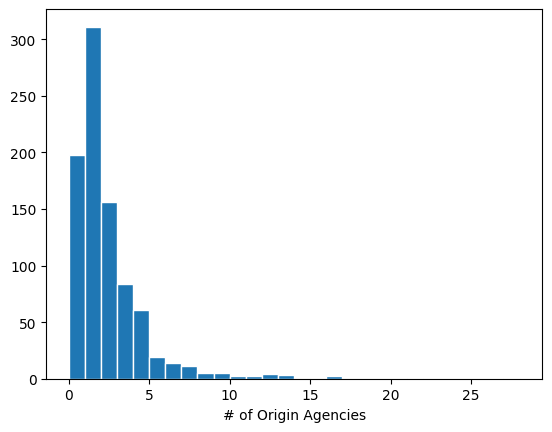

In [311]:
# Distribution of # of agencies that an agency receives fired officers from

in_degrees = [deg for agency , deg in G.in_degree()]
in_bins = range(min(in_degrees), max(in_degrees) + 2)

plt.hist(in_degrees, bins=in_bins, edgecolor="white")
plt.xlabel("# of Origin Agencies")
plt.show()

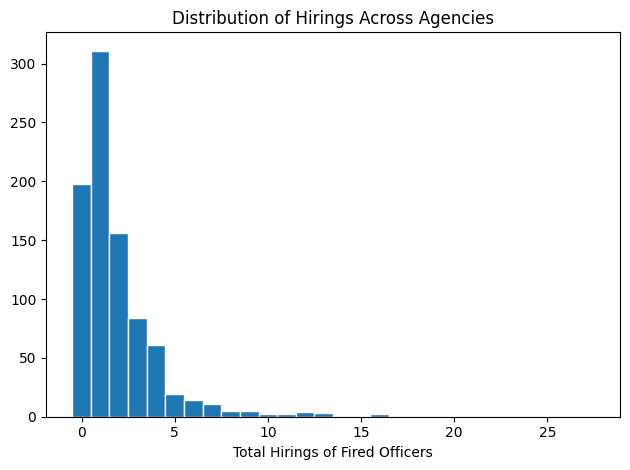

In [214]:
# Distribution of # of hirings 

weighted_in_degrees = dict(G.in_degree(weight="weight"))
values = list(weighted_in_degrees.values())
weighted_in_bins = range(min(values), max(values) + 2)

plt.hist(values, bins=weighted_in_bins, align="left", edgecolor="white")
plt.xlabel("Total Hirings of Fired Officers")
plt.title("Distribution of Hirings Across Agencies")
plt.tight_layout()
plt.show()

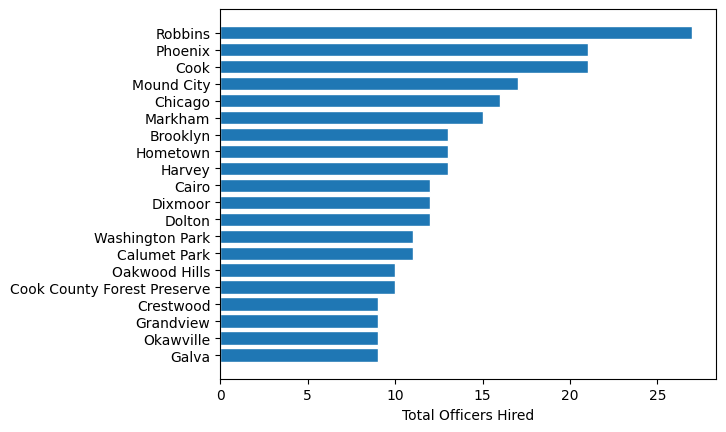

In [281]:
# Identify agencies with highest total hirings of fired officers

def get_value(item):
    return item[1]

rehire_counts = sorted(weighted_in_degrees.items(), 
                       key=get_value, 
                       reverse=True)

nodes, counts = zip(*rehire_counts)

rehire_counts_df = pl.DataFrame({
    "agency_name": list(nodes), 
    "count": list(counts)
    }
)

# Combine Cook County Sheriffs into one 

rehire_counts_df = (
    rehire_counts_df.with_columns(
    pl.col("agency_name").str
    .replace(" Police Department", "")
    .replace(
        {"Cook County Sheriff's Police": "Cook",
         "Cook County Department Of Corrections": "Cook",
         "Cook County Sheriff's Office": "Cook",
         "Cook County Court Services": "Cook",
         "Cook County Forest Pres District Police": "Cook County Forest Preserve",
         "Mounds": "Mound City",
         }
    )
    .alias("pub_agency_name"))
    .group_by("pub_agency_name")
    .agg(pl.col("count").sum(),
         pl.col("agency_name"))
    .sort("count", descending=True)
)

# Take top 20 

N = 20
top = rehire_counts_df.head(N)

plt.barh(range(N), top["count"].to_list(), edgecolor="white")
plt.yticks(range(N), top["pub_agency_name"].to_list())
plt.xlabel("Total Officers Hired")
plt.gca().invert_yaxis() 
plt.show()

In [ ]:
# Use years of re-hiring to extract UCR employee information 

original_names = []
for sublist in top["agency_name"].to_list():
    for name in sublist:
        original_names.append(name)

rehire_years = (
    next_hire
    .with_columns(
        pl.col("start_date").dt.year().alias("data_year")
    )
    .filter(pl.col("agency_name").is_in(original_names))
    .select(["agency_name", "data_year"])
    .unique()
    ).join(
            top.explode("agency_name").select(["agency_name", "pub_agency_name"]),
            on="agency_name",
            how="left"
)

In [341]:
# Merge in officer count for those years or closest years

ucr = ucr_employees.select(["pub_agency_name", "data_year", "total_pe_ct"])

matched_employees = (
    rehire_years
    .join(ucr, on="pub_agency_name", how="left")
    .with_columns(
        (pl.col("data_year") - pl.col("data_year_right")).abs().alias("year_diff")
    )
    .sort("year_diff")
    .group_by(["pub_agency_name", "data_year"])
    .agg(
        pl.first("total_pe_ct"),
        pl.first("data_year_right")
    )
)

avg_employee_size = (
    matched_employees
    .group_by("pub_agency_name")
    .agg(pl.col("total_pe_ct").sum().alias("sum_pe_ct"))
)

average = (
    top
    .join(avg_employee_size, on="pub_agency_name", how="left")
    .with_columns(
        (pl.col("count") / pl.col("sum_pe_ct")).alias("wandering_per_emp")
    )
).sort("wandering_per_emp", descending=True)

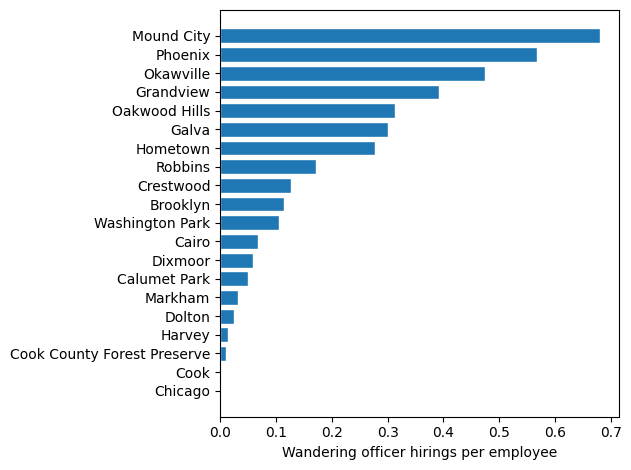

In [342]:
names = average["pub_agency_name"].to_list()
values = average["wandering_per_emp"].to_list()

plt.barh(range(len(names)), values, edgecolor="white")
plt.yticks(range(len(names)), names)
plt.xlabel("Wandering officer hirings per employee")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### Network Visualization

In [ ]:
# Format data for Flowmap

agency_pairs_id = agency_pairs.join(
    police_locations_df[["agency_name", "id"]], on="agency_name", how="left"
    )

agency_pairs_id = agency_pairs_id.join(
    police_locations_df[["agency_name", "id"]],
    left_on="agency_name_misconduct",
    right_on="agency_name", how="left", suffix="_misconduct"
    )

agency_pairs_id = agency_pairs_id.drop(["agency_name", "agency_name_misconduct"])
agency_pairs_id = agency_pairs_id.rename({"id":"dest", "id_misconduct":"origin"})
agency_pairs_id = agency_pairs_id.select(['origin', 'dest', 'count'])

agency_flow = agency_pairs_id.with_columns(pl.row_index()).to_pandas().set_index("index")

police_locations = police_locations_df.rename({"agency_name":"name"})
police_locations = police_locations.to_pandas()

# Import helper functions from the DS 20195 Github page for Flowmap

!pip install -q "git+https://github.com/ds-20195/notebooks#egg=ds20195&subdirectory=lib"
from ds20195 import google_sheets_credentials, generate_flow_sheet
sheet_creds = google_sheets_credentials()

flow_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=police_locations,
    sheet_title="DATA 20195: Wandering Officer Flows",
    flow_title="Illinois wandering officer flows, 2000-Present",
    incoming_tooltip="Officer in",
    outgoing_tooltip="Officer out",
    flow_tooltip="Officer",
    total_unit="officer",
    data_source_name="National Police Index",
    data_source_url="https://national.cpdp.co/",
    flows={"2000-Present": agency_flow},
)

print(flow_sheet.url)
print(f"https://www.flowmap.blue/{flow_sheet.url.split('/')[-1]}")

##### Conclusion

The network analyses provide a general description of the network of Illinois wandering officers. Most agencies receive officers from about 1 to 3 agencies and hire about 1 to 3 previously fired officers between 2000 and the present.

The right-skewed distribution of weighted in-degrees suggests that a small number of agencies dominate in re-hiring fired officers. The top 20 agencies that hired the most fired officers had hired between 9 and 27, some of the largest being the Robbins Police Department, Phoenix Police Department, Chicago Police Department, and Cook County Department of Corrections.

It is important to note that agencies can have significantly different numbers of employees, and agency size is an important factor when identifying re-hiring hubs. Normalizing in-degrees by agency size is possible to an extent, using the FBI's Law Enforcement Employees dataset from the Uniform Crime Reporting (UCR) program. However, this introduces some limitations, one of which is that reporting employee size to the UCR program is voluntary and not every agency is included in the dataset. Also, it is not entirely clear  which exact agencies are included due to its shortened agency naming conventions. 

Thus, the normalized figures is a rough sanity check rather than a definitive ranking. Robbins is also on this list, which is an agency often cited as a case study of a "dumping ground for police officers with troubled histories," according to [Illinois Answers Project](https://illinoisanswers.org/2024/05/06/robbins-police-department-most-hires-of-recently-fired-cops/). Robbins Mayor Darren Bryant has said, "Just because you got fired doesn’t mean you can’t grow or you can’t learn from your last job." 

I would also flag additional police agencies I've found through this analysis, including those in Mound City, Phoenix, Okawville, Grandview, Oakwood Hills, Galva and Hometown. 

As the next step, I will try to verify the UCR dataset by digging further into other available datasets, such as one from the Illinois Law Enforcement Training and Standards Board (ILETSB). I also aim to incorporate Census data to identify any demographic patterns among these problematic agencies, and to apply Moran's I to assess whether they are regionally concentrated.